In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(device)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/jmacedo/anaconda3/envs/ACA/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mps


# Autoencoders

Autoencoders are a type of artificial neural network used for unsupervised learning. They work by compressing input data into a latent-space representation and then reconstructing the data from this representation. So, if all goes well, at the end of the process we obtain the same thing that we input. This may seem conterintuitive, but it is actually very useful for dimensionality reduction. 

As an example, supose that you are interested in sending a large data file over the network. Using an autoencoder, you could convert your data to a latent space representation to obtain a smaller file, that can be sent faster through the network and reconstructed by the receiver.


The architecture of an Autoencoder is depicted in the picture below:

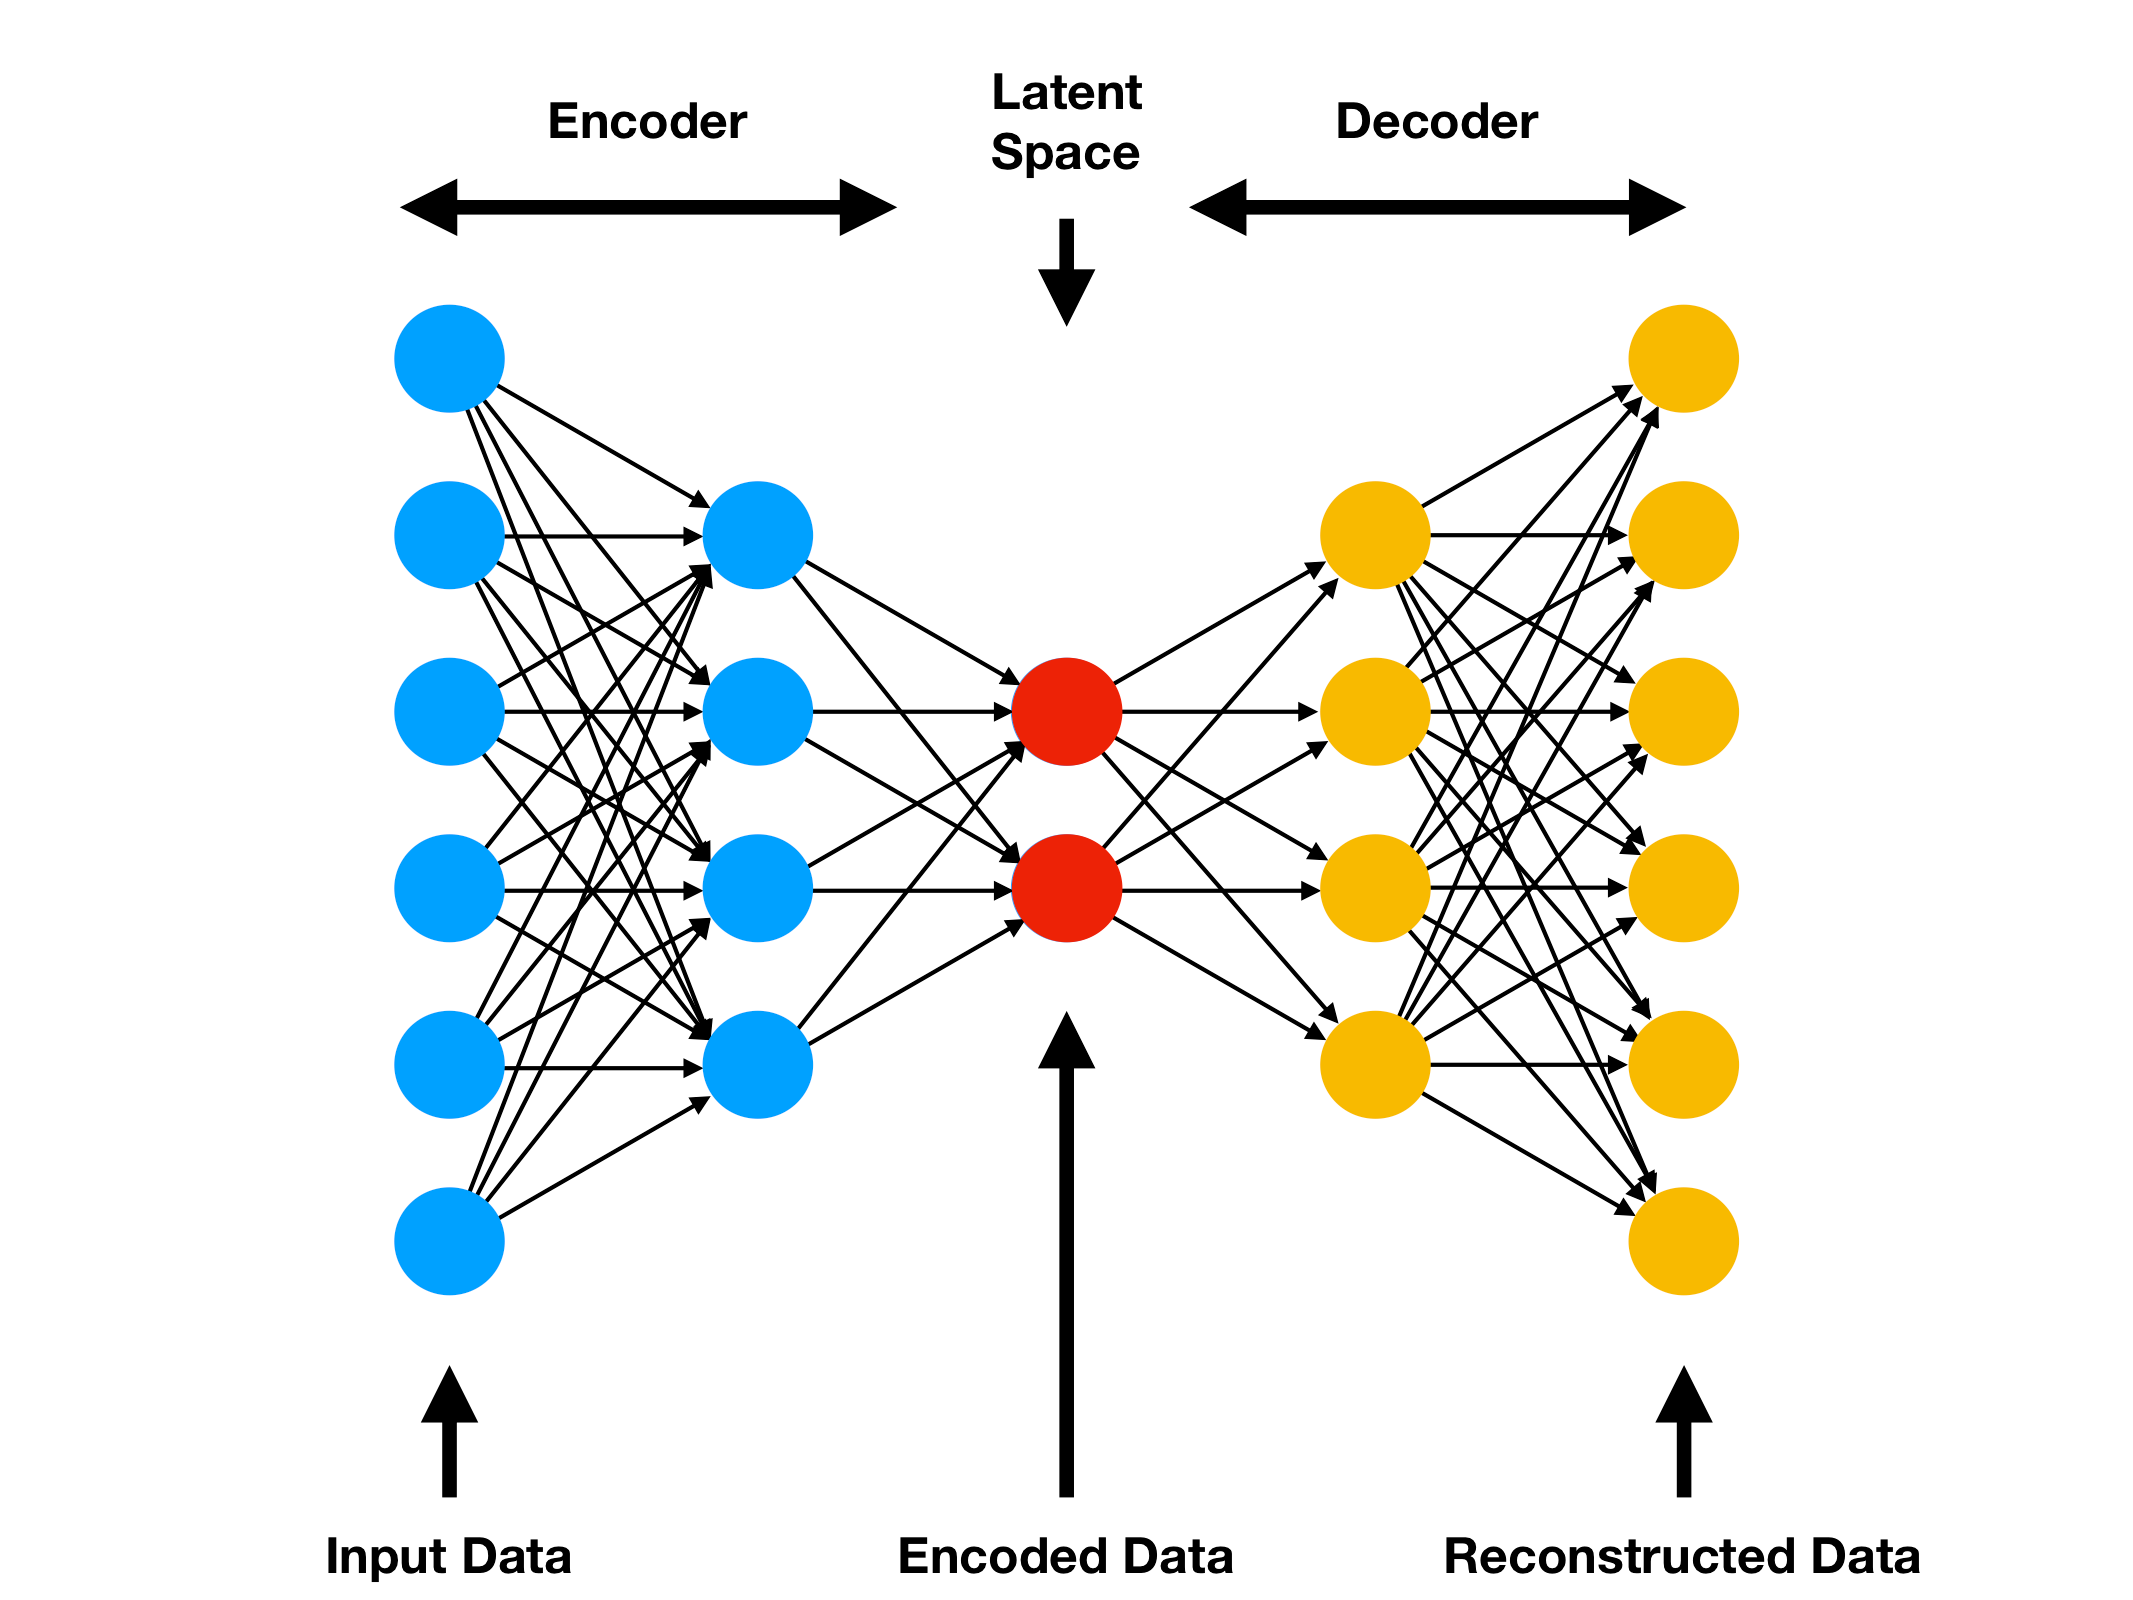


As you can see, it can be decomposed into three components: an encoder, a latent space and a decoder:

- Encoder: The encoder network takes the input data and passes it through a series of hidden layers that map it into a lower-dimensional latent-space representation. 

- Latent Space: The latent space, represented in red, refers to the hidden layer in-between the encoder and decoder and contains the compressed representation of the input data generated by the encoder. 
    
- Decoder: The decoder network takes the latent-space representation of the input and reconstructs the original data. It does so be reversing the encoder process, passing the latent-space representation of the data through a series of hidden-layers that progressively increase its dimensionality, finally reconstructing the original data. 

Autoencoders can be trained using various optimization techniques, such as gradient descent, to minimize the difference between the input data and the reconstructed output. Apart from the aforementioned applications for dimensionality reduction, these models may also be applied for anomaly detection, data denoising and generative modeling. 


In this class we are going to focus in dimensionality reduction, attempting to create a compact representation of data that can be well reconstructed.

Let's start by loading the dataset, and here we are going to use the MNIST dataset

In [2]:
transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: torch.flatten(x))])
mnist_data_flattened = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

data_loader_flattened = torch.utils.data.DataLoader(dataset=mnist_data_flattened,
                                          batch_size=64,
                                          shuffle=True)

Note that we flattened the samples already. This is important for the architecture that we are going to use. Another important aspect is to know the range of values in our samples, which we can do with the following code:

In [3]:
dataiter_flattened = iter(data_loader_flattened)
images, labels = next(dataiter_flattened)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


Considering that our data ranges between 0 and 1, we can define the following architecture (note the activation function at the input).

This architecture is based on two blocks: the encoder and decoder. Both blocks are composed only by fully connected layers, with the encoder progressively reducing the size of the layers and the decoder progressively increasing it.

In [4]:
class Autoencoder_Linear(nn.Module):
    def __init__(self, color_channels=1, width=28, height=28):
        super().__init__()        
        self.target_width = width
        self.target_height = height
        self.target_color_channels = color_channels
        self.encoder = nn.Sequential(
            nn.Linear(self.target_color_channels * self.target_height * self.target_width, 128), # (BatchSize, Width*Height) -> (BatchSize, 128)
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)
        )
        

        self.decoder = nn.Sequential(
            #TODO: Implement the decoder part of the autoencoder
            #Remember that the activation function of the last layer 
            #depends on the range of the input values
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    


Now we can define the training function for our model, which is very simillar to what we've done in previous classes. The main diference is that the sample and target are the same. 

In [40]:

def train(model, data_loader, num_epochs=50, device='cpu'):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),
                                lr=1e-3, 
                                weight_decay=1e-5)


    model = model.to(device)
    
    outputs = []
    for epoch in range(num_epochs):
        for (img, _) in data_loader:
            #TODO: Implement the training loop
            #Remember to move the data to the device and that
            #the training loop should be similar to the one of
            #a regular neural network
            pass
            
            
        print(f'Epoch:{epoch+1}, Loss:{loss.item():.4f}')
        outputs.append((epoch, img.to('cpu'), recon.to('cpu')))
        
    
    return model.to('cpu'), outputs



And finally we can create an instance of our model and train it.

In [6]:
num_epochs = 5
linear_model = Autoencoder_Linear()
linear_model, outputs = train(linear_model, data_loader_flattened, num_epochs=num_epochs, device=device)

Epoch:1, Loss:0.0442
Epoch:2, Loss:0.0438
Epoch:3, Loss:0.0394
Epoch:4, Loss:0.0393
Epoch:5, Loss:0.0351


Having a trained model, we can plot its outputs to see how good of an approximation we've got.

In [7]:
def plot_results(outputs, num_epochs, color_channels=1, width=28, height=28):
    for k in range(0, num_epochs, 1):
        plt.figure(figsize=(9, 2))
        plt.gray()
        imgs = outputs[k][1].detach().numpy()
        recon = outputs[k][2].detach().numpy()

        
        for i, item in enumerate(imgs):
            if i >= 9: break
            plt.subplot(2, 9, i+1)
            plt.axis('off')

            if color_channels == 1:
                plt.imshow(item.reshape(height, width))
            else:
                item = item.reshape(color_channels,height, width)
                plt.imshow(np.transpose(item, (1,2,0)))
    
        for i, item in enumerate(recon):
            if i >= 9: break
            plt.subplot(2, 9, 9+i+1)
            
            plt.axis('off')
            if color_channels == 1:
                plt.imshow(item.reshape(height, width))
            else:
                item = item.reshape(color_channels,height, width)
                plt.imshow(np.transpose(item, (1,2,0)))




32


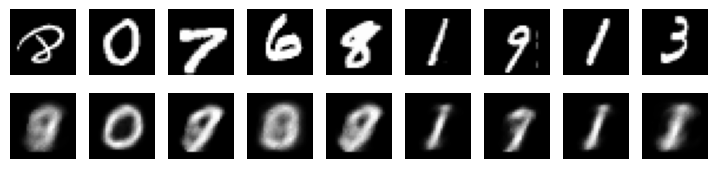

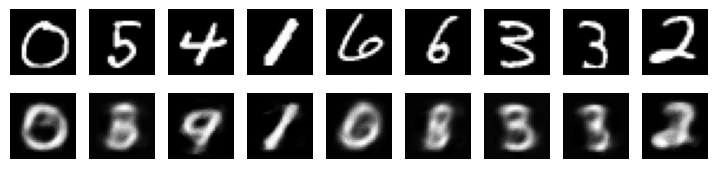

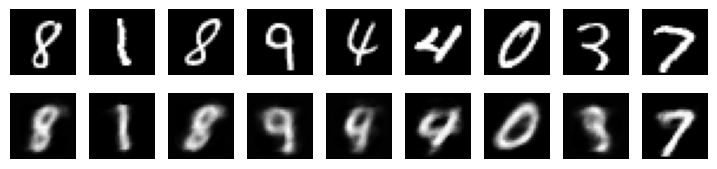

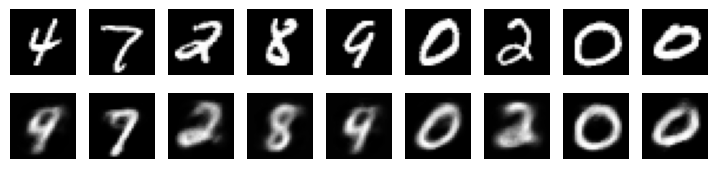

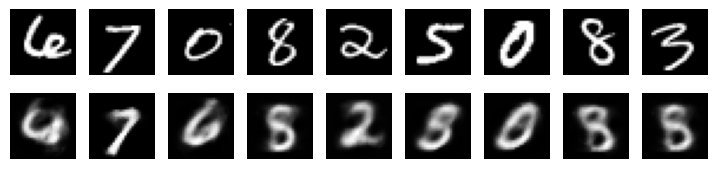

In [8]:
print(len(outputs[0][1]))
plot_results(outputs, num_epochs, color_channels=1, width=28, height=28)

As you can see, it is not perfect, but close enough. So how does it work with more complex problems?

Let's try with CIFAR 10. We start by loading the data once again.

In [9]:
transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view( -1))])
data_flattened = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

data_loader_flattened = torch.utils.data.DataLoader(dataset=data_flattened,
                                          batch_size=64,
                                          shuffle=True)

dataiter_flattened = iter(data_loader_flattened)
images, labels = next(dataiter_flattened)
print(torch.min(images), torch.max(images))
print(images.shape)



Files already downloaded and verified
tensor(0.) tensor(1.)
torch.Size([64, 3072])


Epoch:1, Loss:0.0381
Epoch:2, Loss:0.0340
Epoch:3, Loss:0.0273
Epoch:4, Loss:0.0348
Epoch:5, Loss:0.0380


"\ncriterion = nn.MSELoss()\noptimizer = torch.optim.Adam(linear_model.parameters(),\n                             lr=1e-3, \n                             weight_decay=1e-5)\n\nnum_epochs = 50\n\noutputs = []\nfor epoch in range(num_epochs):\n    for (img, _) in data_loader_flattened:\n        # img = img.reshape(-1, 28*28) # -> use for Autoencoder_Linear\n        recon = linear_model(img)\n        loss = criterion(recon, img)\n        \n        optimizer.zero_grad()\n        loss.backward()\n        optimizer.step()\n\n    print(f'Epoch:{epoch+1}, Loss:{loss.item():.4f}')\n    outputs.append((epoch, img, recon))\n"

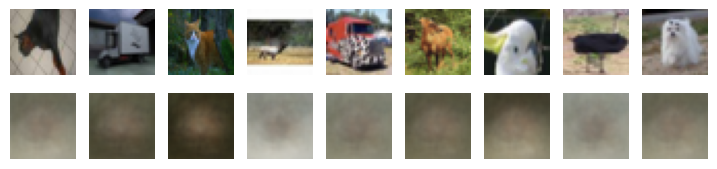

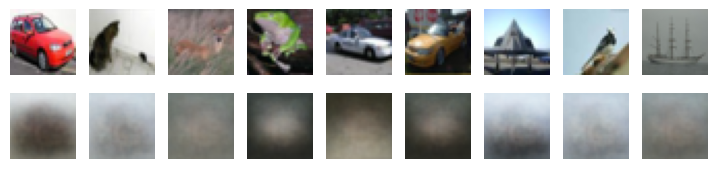

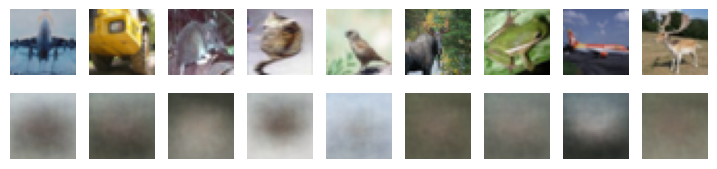

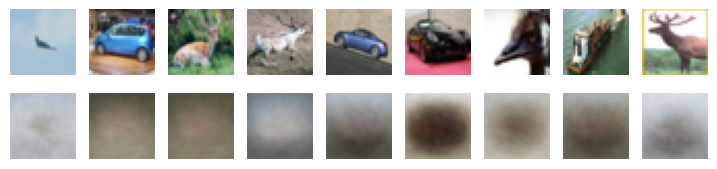

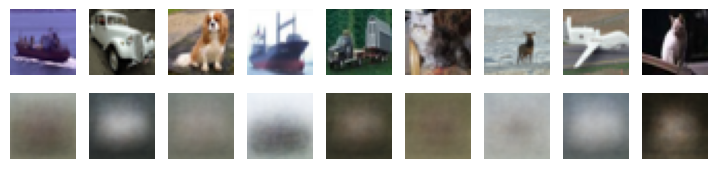

In [10]:
color_channels = 3
width = 32
height = 32
linear_model = Autoencoder_Linear( color_channels=3, width=32, height=32)
linear_model, outputs = train(linear_model, data_loader_flattened, num_epochs=num_epochs, device=device)

plot_results(outputs, num_epochs, color_channels, width, height)

As you can see, the results are very poor. As we've seen in previous classes, MLPs often perform poorly when taking images as input. Here we can also see that they are unable to reconstruct more complex images.

However, we are not stuck with using only fully connected layers. In fact, Autoencoders may have different types of layers to support different types of inputs (as shown in the image below).

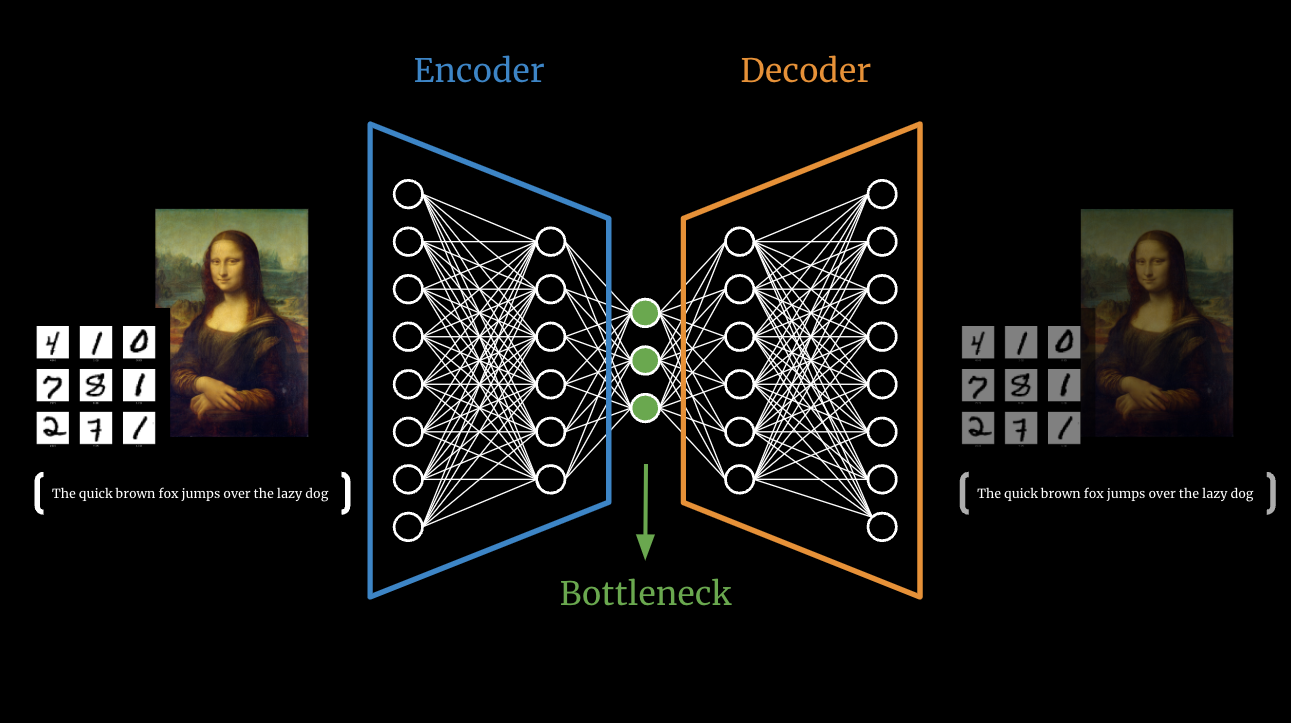

So let's define a new autoencoder, using only convolutional layers instead.

In [56]:
class Autoencoder(nn.Module):
    def __init__(self, color_channels=1, width=32, height=32):
        super().__init__()        
        self.encoder = nn.Sequential(
            nn.Conv2d(color_channels, 16, 3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 8)
        )
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 8),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, color_channels, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
 

Considering that we had flattened the dataset, it is actually easier to just reload it once again.

In [52]:
transform = transforms.ToTensor()
data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(dataset=data,
                                          batch_size=64,
                                          shuffle=True)

dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))
print(images.shape)



Files already downloaded and verified
tensor(0.) tensor(1.)
torch.Size([64, 3, 32, 32])


And we can re-use the same function as before to train the new autoencoder.

In [59]:
color_channels = 3
width = 32
height = 32
model = Autoencoder(3, 32, 32)
model, outputs = train(model, data_loader, num_epochs=num_epochs, device=device)


Epoch:1, Loss:0.0152
Epoch:2, Loss:0.0123
Epoch:3, Loss:0.0098
Epoch:4, Loss:0.0088
Epoch:5, Loss:0.0100
Epoch:6, Loss:0.0081
Epoch:7, Loss:0.0074
Epoch:8, Loss:0.0088
Epoch:9, Loss:0.0111
Epoch:10, Loss:0.0089


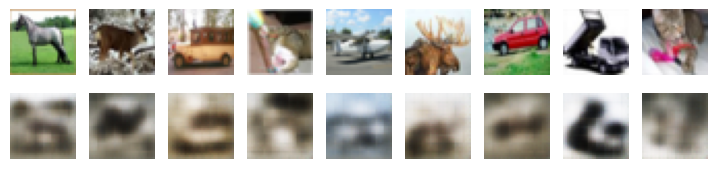

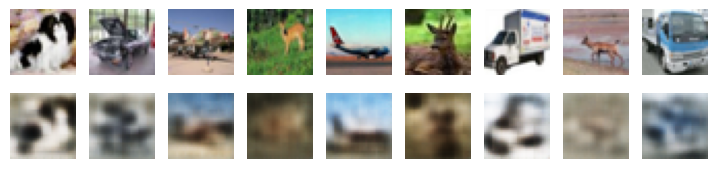

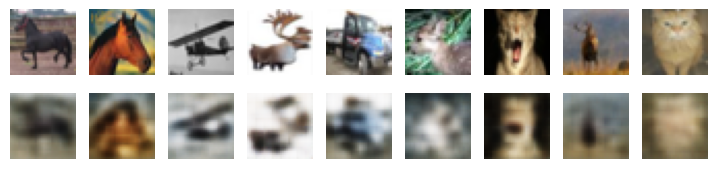

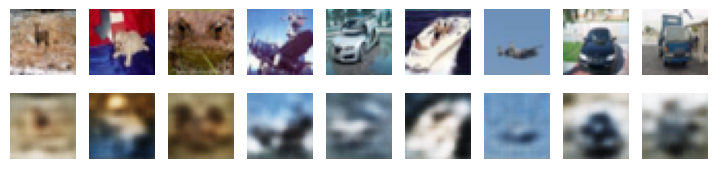

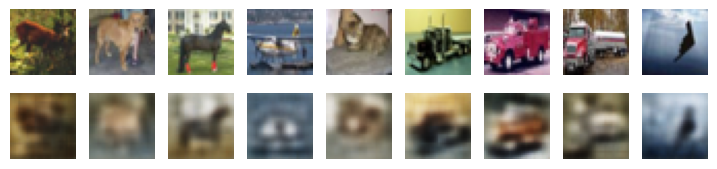

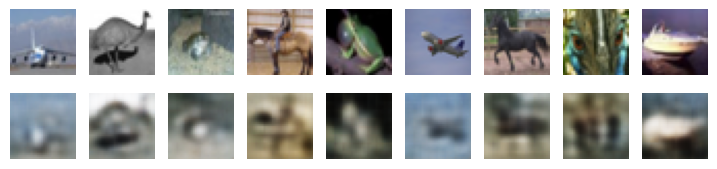

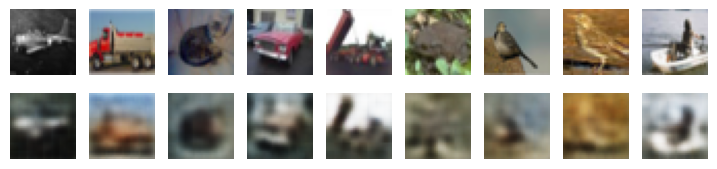

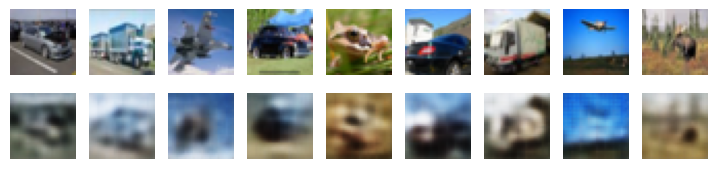

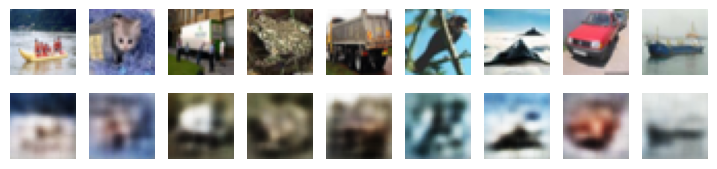

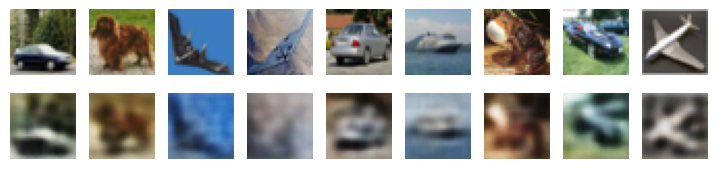

In [61]:
plot_results(outputs, num_epochs, color_channels, width, height)

The results are better, but not perfect. Now its up to you! Tweak the architectures to get the best reconstruction of the original data.

In [ ]:
class AutoencoderTweaked(nn.Module):
    pass
